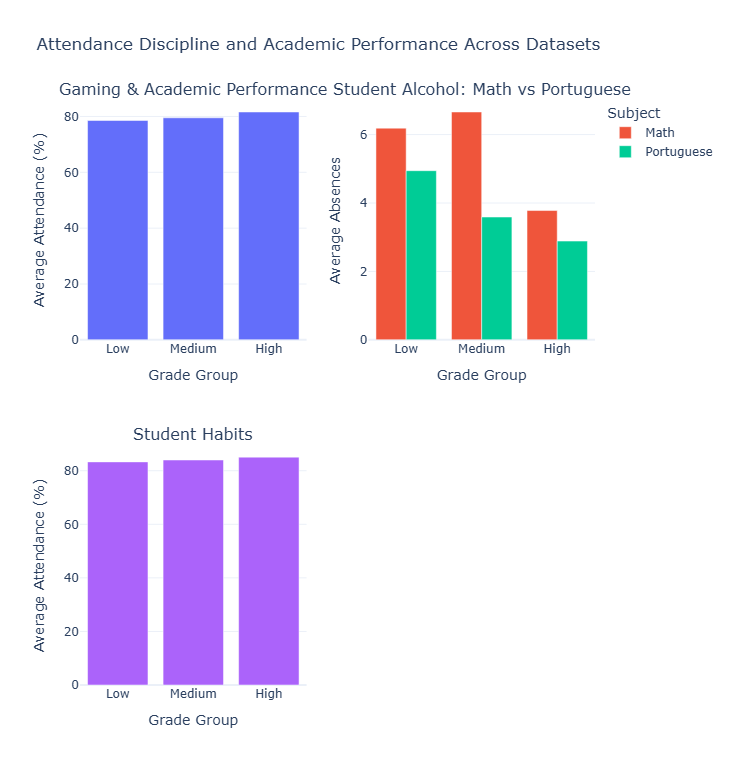

In [1]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load data
df2 = pd.read_csv("Gaming_Academic_Performance.csv")
df3_mat = pd.read_csv("student-mat.csv", sep=None, engine="python")
df3_por = pd.read_csv("student-por.csv", sep=None, engine="python")
df4 = pd.read_csv("student_habits_performance.csv")

# Combine Dataset 3
df3_mat["Subject"] = "Math"
df3_por["Subject"] = "Portuguese"
df3 = pd.concat([df3_mat, df3_por], ignore_index=True)

# Create balanced Grade Group
def add_grade_group(df, grade_col):
    df = df.copy()
    df["Grade Group"] = pd.qcut(
        df[grade_col].rank(method="first"),
        q=3,
        labels=["Low", "Medium", "High"]
    )
    return df

df2 = add_grade_group(df2, "grades")
df3 = add_grade_group(df3, "G3")
df4 = add_grade_group(df4, "exam_score")

grade_order = ["Low", "Medium", "High"]

# Summaries
s2 = (
    df2.groupby("Grade Group", observed=False)["attendance"]
    .mean()
    .reindex(grade_order)
)

s3 = (
    df3.groupby(["Grade Group", "Subject"], observed=False)["absences"]
    .mean()
    .reset_index()
)

s4 = (
    df4.groupby("Grade Group", observed=False)["attendance_percentage"]
    .mean()
    .reindex(grade_order)
)

# Figure
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Gaming & Academic Performance",
        "Student Alcohol: Math vs Portuguese",
        "Student Habits",
        ""
    ],
    vertical_spacing=0.18,
    horizontal_spacing=0.12
)

# Dataset 2: Attendance
fig.add_trace(
    go.Bar(
        x=grade_order,
        y=s2.values,
        showlegend=False
    ),
    row=1,
    col=1
)

# Dataset 3: Absences by Subject
for subject in ["Math", "Portuguese"]:
    temp = (
        s3[s3["Subject"] == subject]
        .set_index("Grade Group")
        .reindex(grade_order)
    )
    fig.add_trace(
        go.Bar(
            x=grade_order,
            y=temp["absences"],
            name=subject
        ),
        row=1,
        col=2
    )

# Dataset 4: Attendance
fig.add_trace(
    go.Bar(
        x=grade_order,
        y=s4.values,
        showlegend=False
    ),
    row=2,
    col=1
)

fig.update_layout(
    title_text="Attendance Discipline and Academic Performance Across Datasets",
    barmode="group",
    height=750,
    width=1000,
    template="plotly_white",
    legend_title_text="Subject"
)

fig.update_xaxes(title_text="Grade Group")
fig.update_yaxes(title_text="Average Attendance (%)", row=1, col=1)
fig.update_yaxes(title_text="Average Absences", row=1, col=2)
fig.update_yaxes(title_text="Average Attendance (%)", row=2, col=1)

fig.show()